**In order to get the fastest trainings you need to enable GPUs for the notebook:**
* Navigate to Edit→Notebook Settings
* select GPU from the Hardware Accelerator drop-down
(https://colab.research.google.com/notebooks/gpu.ipynb#scrollTo=oM_8ELnJq_wd)

In [1]:
# Some installations upfront
!git clone https://github.com/automl/PFNs.git
!cd PFNs; pip install -e .; cd -

fatal: destination path 'PFNs' already exists and is not an empty directory.
Obtaining file:///content/PFNs
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for pfns (pyproject.toml) ... done
  Created wheel for pfns: filename=pfns-0.4.2-py3-none-any.whl size=7856 sha256=6d694c2046379aa22a1962299ddc788a09f71bfaf1a28ca0a28d68e3d97d17e6
  Stored in directory: /tmp/pip-ephem-wheel-cache-0rbnurtk/wheels/bc/60/a7/723f250656dc79097d6a23c95a4e6d3949685d9bd67c0db6ab
Successfully built pfns
  Attempting uninstall: pfns
    Found existing installation: pfns 0.4.2
    Uninstalling pfns-0.4.2:
      Successfully uninstalled pfns-0.4.2
/content


In [2]:
# if this import fails, please restart the notebook:
# 1. click on "Runtime"
# 2. click "Restart session"
try:
    import pfns
except ImportError:
    raise ImportError("Please restart runtime by i) clicking on \'Runtime\' and then ii) clicking \'Restart session\'")

In [3]:
from pfns.priors import Batch
import torch
import matplotlib.pyplot as plt

## Let's train our first PFN to do ridge regression

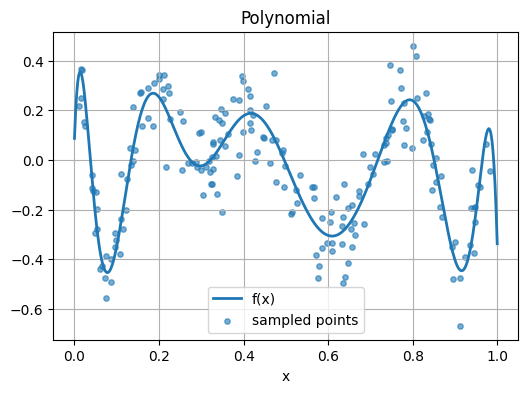

In [4]:
# === Plot function + scattered noisy samples ===

import torch
import matplotlib.pyplot as plt

# Parameters (match your generator)
degree = 12
num_points = 400
num_scatter = 200
a = 0.1  # observation noise
b = 0.1   # weight std

# ----- Smooth function -----
xs = torch.linspace(0, 1, num_points).view(1, -1, 1)
t = 2 * xs - 1

T0 = torch.ones_like(t)
T1 = t
cheb = [T1]

prev2, prev1 = T0, T1
for _ in range(2, degree + 1):
    Tk = 2 * t * prev1 - prev2
    cheb.append(Tk)
    prev2, prev1 = prev1, Tk

phi_x = torch.cat(cheb + [torch.ones_like(t)], dim=-1)

ws = torch.distributions.Normal(
    torch.zeros(phi_x.shape[-1]), b
).sample()

y_mean = torch.einsum('nmf,f->nm', phi_x, ws)

# ----- Noisy scattered points -----
xs_scatter = torch.rand(1, num_scatter, 1)
t_scatter = 2 * xs_scatter - 1

T0s = torch.ones_like(t_scatter)
T1s = t_scatter
cheb_s = [T1s]

prev2, prev1 = T0s, T1s
for _ in range(2, degree + 1):
    Tk = 2 * t_scatter * prev1 - prev2
    cheb_s.append(Tk)
    prev2, prev1 = prev1, Tk

phi_scatter = torch.cat(cheb_s + [torch.ones_like(t_scatter)], dim=-1)

y_scatter = torch.einsum('nmf,f->nm', phi_scatter, ws)
y_scatter += a * torch.randn_like(y_scatter)

# ----- Plot -----
plt.figure(figsize=(6, 4))
plt.plot(xs[0, :, 0].numpy(), y_mean[0].numpy(), linewidth=2, label="f(x)")
plt.scatter(
    xs_scatter[0, :, 0].numpy(),
    y_scatter[0].numpy(),
    s=15,
    alpha=0.6,
    label="sampled points"
)
plt.title("Polynomial")
plt.xlabel("x")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
def get_batch_poly(batch_size=10, seq_len=100, num_features=1,
                   degree=12, hyperparameters=None, device='cuda', **kwargs):
    if hyperparameters is None:
        hyperparameters = {'a': 0.1, 'b': 0.1}

    xs = torch.rand(batch_size, seq_len, num_features)
    t = 2*xs - 1  # shape (batch, seq, num_features), for num_features=1

    # build Chebyshev T_k(t) recursively (k=0..degree)
    T0 = torch.ones_like(t[..., :1])
    T1 = t[..., :1]
    cheb = [T1]  # start from k=1

    prev2, prev1 = T0, T1
    for _k in range(2, degree + 1):
        Tk = 2*t[..., :1]*prev1 - prev2
        cheb.append(Tk)
        prev2, prev1 = prev1, Tk

    phi_x = torch.cat(cheb + [torch.ones_like(t[..., :1])], dim=-1)

    ws = torch.distributions.Normal(
        torch.zeros(phi_x.shape[-1]), hyperparameters['b']
    ).sample((batch_size,))

    ys = torch.distributions.Normal(
        torch.einsum('nmf,nf->nm', phi_x, ws),
        hyperparameters['a']
    ).sample()[..., None]
    # ys = torch.einsum('nmf,nf->nm', phi_x, ws)

    return Batch(x=xs.to(device), y=ys.to(device), target_y=ys.to(device))

batch = get_batch_poly(batch_size=1, seq_len=500, degree=12, hyperparameters = {'a': 0.1, 'b': .1})
for dataset_index in range(len(batch.x)):
    plt.scatter(batch.x[dataset_index,:,0].numpy(), batch.y[dataset_index,:].numpy())


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

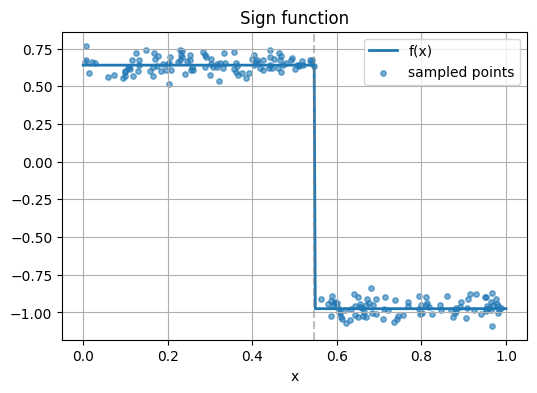

In [82]:
# === Plot sign (step) function + scattered noisy samples ===

import torch
import matplotlib.pyplot as plt

# Parameters
num_curve = 400
num_scatter = 200
a = 0.05           # observation noise
tau = torch.rand(1).item()  # jump location in (0,1)
jump_std = 1.0     # jump height std
base_std = 0.5     # base level std

# ---- Sample function parameters ONCE ----
c1 = torch.distributions.Normal(0.0, base_std).sample()
jump = torch.distributions.Normal(0.0, jump_std).sample()
c2 = c1 + jump

# ---- Smooth (step) function ----
xs = torch.linspace(0, 1, num_curve).view(1, -1, 1)
x0 = xs[..., 0]

y_mean = torch.where(
    x0 < tau,
    c1,
    c2
)

# ---- Noisy scattered samples ----
xs_scatter = torch.rand(1, num_scatter, 1)
x0s = xs_scatter[..., 0]

y_scatter = torch.where(
    x0s < tau,
    c1,
    c2
)
y_scatter += a * torch.randn_like(y_scatter)

# ---- Plot ----
plt.figure(figsize=(6, 4))
plt.plot(xs[0, :, 0].numpy(), y_mean[0].numpy(), linewidth=2, label="f(x)")
plt.scatter(
    xs_scatter[0, :, 0].numpy(),
    y_scatter[0].numpy(),
    s=15,
    alpha=0.6,
    label="sampled points"
)

plt.axvline(tau, linestyle="--", color="gray", alpha=0.5)
plt.title("Sign function")
plt.xlabel("x")
plt.legend()
plt.grid(True)
plt.show()


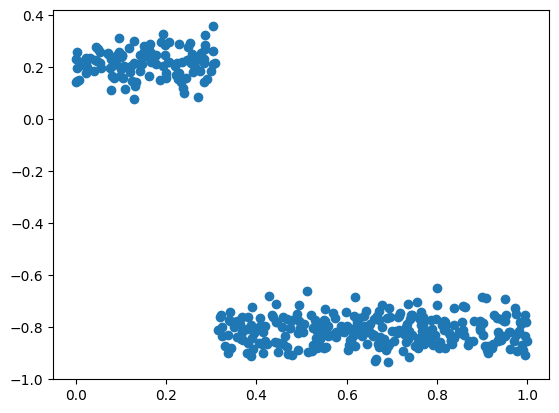

In [74]:
def get_batch_sign(
    batch_size=10,
    seq_len=100,
    num_features=1,
    hyperparameters=None,
    device='cpu',
    **kwargs
):
    if hyperparameters is None:
        hyperparameters = {
            'a': 0.05,        # observation noise
            'jump_std': 1.0,  # jump height std
            'base_std': 0.5   # base level std
        }

    # Inputs
    xs = torch.rand(batch_size, seq_len, num_features)

    # Step parameters per function
    tau = torch.rand(batch_size)                     # jump location in (0,1)
    c1 = torch.distributions.Normal(
        0.0, hyperparameters['base_std']
    ).sample((batch_size,))
    jump = torch.distributions.Normal(
        0.0, hyperparameters['jump_std']
    ).sample((batch_size,))
    c2 = c1 + jump

    x0 = xs[..., 0]

    # True sign / step function
    mean_ys = torch.where(
        x0 < tau[:, None],
        c1[:, None],
        c2[:, None]
    )

    # Noisy observations
    ys = torch.distributions.Normal(
        mean_ys,
        hyperparameters['a']
    ).sample()

    return Batch(
        x=xs.to(device),
        y=ys[..., None].to(device),
        target_y=mean_ys[..., None].to(device)
    )


batch = get_batch_sign(batch_size=1, seq_len=400)
for dataset_index in range(len(batch.x)):
    plt.scatter(batch.x[dataset_index,:,0].numpy(), batch.y[dataset_index,:].numpy())


## Train Train Train!!!

### Let's train a mini PFN for 1D datasets with up to 20 elements 🚀

This should take around 1 minute, at least on my machine it does.

#### What happens during training?
During training we sample datasets from our `get_batch` method, we then split them into left and right of the so called `single_eval_pos` (which in turn is sampled uniformly at random). If something is left it is training, on the right it is test. Now our PFN is training to predict the $y$ of the test set, given $x$ and $y$ for the training set, as well as $x$ for the test set.

Our training uses standard Adam and a cross-entropy loss. We use a transformer as PFN, where each example in the training or test set is encoded as a token (sometimes also called time step). More info on the architecture can be found in our paper.

In [27]:
import math

from torch import nn
from pfns import utils
from pfns.model import bar_distribution
from pfns.train import train, MainConfig, OptimizerConfig, TransformerConfig, BatchShapeSamplerConfig
from pfns.model.encoders import EncoderConfig
from pfns.model.bar_distribution import BarDistributionConfig
from pfns.priors.prior import AdhocPriorConfig

# Let's fix some global settings

hps = None
num_features = 1
max_dataset_size = 20


def train_a_pfn(get_batch_function, epochs=20, num_features=num_features, max_dataset_size=max_dataset_size, hps=hps, batch_size=256, steps_per_epoch=100):

    # define a bar distribution (riemann distribution) criterion with 1000 bars
    ys = get_batch_function(100000,20, num_features, hyperparameters=hps).target_y
    # we define our bar distribution adaptively with respect to the above sample of target ys from our prior
    borders = bar_distribution.get_bucket_borders(num_outputs=1_000, ys=ys).tolist()

    config = MainConfig(
        priors=[AdhocPriorConfig(get_batch_methods=[get_batch_function], prior_kwargs={'num_features': num_features, 'hyperparameters': hps})],
        optimizer=OptimizerConfig('adamw', lr=.0003),
        model=TransformerConfig(
            criterion=BarDistributionConfig(full_support=True, borders=borders),
            emsize=512, nhead=8, nhid=1024, nlayers=6,
            features_per_group=1, attention_between_features=False,
            # The encoder config ensures the uniform inputs between 0 and 1 have mean 0 and var 1
            encoder=EncoderConfig(constant_normalization_mean=.5, constant_normalization_std=math.sqrt(1/12),)
        ),
        batch_shape_sampler=BatchShapeSamplerConfig(batch_size=batch_size, max_seq_len=max_dataset_size,
                                                    min_num_features=num_features, max_num_features=num_features),
        epochs=epochs, warmup_epochs=epochs//4, steps_per_epoch=steps_per_epoch,
        num_workers=0,
    )
    train_result = train(config, device='cuda', reusable_config=False)
    return train_result

In [28]:
model_poly = train_a_pfn(get_batch_poly)['model']

init dist
Not using distributed
ALL: Using device cuda.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_poly (batch_size=10, seq_len=100, num_features=1, degree=12, hyperparameters=None, device='cuda', **kwargs)
), num_features=1, hyperparameters=None), 'num_steps': 100, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=256, min_single_eval_pos=0, max_seq_len=20, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'cuda', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_poly (batch_size=10, seq_len=100, num_features=1, degree=12, hyperparameters=None, device='cuda', **kwargs)
), num_features=1, hyperparameters=None), 'num_ste

In [75]:

model_sign = train_a_pfn(get_batch_sign)['model']

init dist
Not using distributed
ALL: Using device cuda.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_sign (batch_size=10, seq_len=100, num_features=1, hyperparameters=None, device='cpu', **kwargs)
), num_features=1, hyperparameters=None), 'num_steps': 100, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=256, min_single_eval_pos=0, max_seq_len=20, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'cuda', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_sign (batch_size=10, seq_len=100, num_features=1, hyperparameters=None, device='cpu', **kwargs)
), num_features=1, hyperparameters=None), 'num_steps': 100, 'batch_shape_s

In [76]:
def get_batch_both(
    batch_size=10,
    seq_len=100,
    num_features=1,
    hyperparameters=None,
    device='cuda',
    **kwargs
):
    # Sample both types
    batch_poly = get_batch_poly(
        batch_size=batch_size,
        seq_len=seq_len,
        num_features=num_features,
        hyperparameters=hyperparameters,
        device=device,
        **kwargs
    )

    batch_pw = get_batch_sign(
        batch_size=batch_size,
        seq_len=seq_len,
        num_features=num_features,
        hyperparameters=hyperparameters,
        device=device,
        **kwargs
    )

    # Random mask per sample
    mask = (torch.rand(batch_size, device=device) < 0.5)

    # Mix within batch
    x = torch.where(mask[:, None, None], batch_poly.x, batch_pw.x)
    y = torch.where(mask[:, None, None], batch_poly.y, batch_pw.y)
    target_y = torch.where(mask[:, None, None], batch_poly.target_y, batch_pw.target_y)

    return Batch(
        x=x,
        y=y,
        target_y=target_y,
    )

model_both_20 = train_a_pfn(get_batch_both, epochs=20)['model']
model_both_40 = train_a_pfn(get_batch_both, epochs=40)['model']


init dist
Not using distributed
ALL: Using device cuda.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_both (batch_size=10, seq_len=100, num_features=1, hyperparameters=None, device='cuda', **kwargs)
), num_features=1, hyperparameters=None), 'num_steps': 100, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=256, min_single_eval_pos=0, max_seq_len=20, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'cuda', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_both (batch_size=10, seq_len=100, num_features=1, hyperparameters=None, device='cuda', **kwargs)
), num_features=1, hyperparameters=None), 'num_steps': 100, 'batch_shape

## Compare loss

In [62]:
import torch
def compute_nll(model, batch, eps=1e-12):
    x = batch.x.transpose(0, 1)
    y = batch.y.transpose(0, 1)
    target_y = batch.target_y.transpose(0, 1)

    with torch.no_grad():
      logits = model(x, y, x)

      borders = model.criterion.borders.to(logits.device)
      bin_centers = 0.5 * (borders[:-1] + borders[1:])


      probs = torch.softmax(logits, dim=-1)
      bin_widths = borders[1:] - borders[:-1]

      bin_idx = torch.bucketize(
          target_y.squeeze(-1),
          borders
      ) - 1

      bin_idx = bin_idx.clamp(0, bin_widths.shape[0] - 1)

      probs_correct = probs.gather(
          dim=-1,
          index=bin_idx.unsqueeze(-1)
      ).squeeze(-1)

      widths = bin_widths[bin_idx]
      density = probs_correct / widths

      nll = -torch.log(density + eps)
      nll = nll.mean().item()

    return nll

def compute_mse_loss(model, batch):
    x = batch.x.transpose(0, 1)
    y = batch.y.transpose(0, 1)
    target_y = batch.target_y.transpose(0, 1)

    with torch.no_grad():
        logits = model(x, y, x)  # (

        probs = torch.softmax(logits, dim=-1)

        borders = model.criterion.borders.to(logits.device)
        bin_centers = 0.5 * (borders[:-1] + borders[1:])

        pred_mean = torch.sum(
            probs * bin_centers.view(1, 1, -1),
            dim=-1,
            keepdim=True
        )

        mse = torch.mean((pred_mean - target_y) ** 2).item()

    return mse




In [90]:
batch_poly = get_batch_poly(seq_len=50, device="cpu")
batch_sign = get_batch_sign(seq_len=50, device="cpu")

print(batch_poly.x.device)


print("Polynomial")
print("nll: ", compute_nll(model_poly, batch_poly))
print("mse: ", compute_mse_loss(model_poly, batch_poly))

print("on other")
print("nll: ", compute_nll(model_poly, batch_sign))
print("mse: ", compute_mse_loss(model_poly, batch_sign))
print()

print("Gauss")
print("nll: ", compute_nll(model_sign , batch_sign))
print("mse: ", compute_mse_loss(model_sign , batch_sign))

print("on other")
print("nll: ", compute_nll(model_sign , batch_poly))
print("mse: ", compute_mse_loss(model_sign , batch_poly))


print()
print("Both 20")
print("nll: ", compute_nll(model_both_20, batch_sign))
print("mse: ", compute_mse_loss(model_both_20, batch_sign))

print("on other")
print("nll: ", compute_nll(model_both_20, batch_poly))
print("mse: ", compute_mse_loss(model_both_20, batch_poly))

print()
print("Both 40")
print("nll: ", compute_nll(model_both_40, batch_sign))
print("mse: ", compute_mse_loss(model_both_40, batch_sign))

print("on other")
print("nll: ", compute_nll(model_both_40, batch_poly))
print("mse: ", compute_mse_loss(model_both_40, batch_poly))

cpu
Polynomial
nll:  -0.5951186418533325
mse:  0.01756446808576584
on other
nll:  1.3674834966659546
mse:  0.28317248821258545

Gauss
nll:  1.5816775560379028
mse:  0.2958361506462097
on other
nll:  0.8107548356056213
mse:  0.02504492551088333

Both 20
nll:  0.1135382205247879
mse:  0.1986769288778305
on other
nll:  -0.7409564852714539
mse:  0.016675235703587532

Both 40
nll:  0.3110511898994446
mse:  0.2633597254753113
on other
nll:  -0.7007171511650085
mse:  0.015731392428278923


In [87]:
models = {
    "Polynomial": model_poly,
    "Sign": model_sign,
    "Both_20": model_both_20,
    "Both_40": model_both_40,
}

get_batches = {
    "Polynomial": get_batch_poly,
    "Sign": get_batch_sign,
}
import numpy as np

def evaluate_models(
    models,
    get_batches,
    num_batches=20,
    seq_len=50,
    device="cpu"
):
    results = {}

    for model_name, model in models.items():
        results[model_name] = {}

        for data_name, get_batch in get_batches.items():
            nlls = []
            mses = []

            for _ in range(num_batches):
                batch = get_batch(seq_len=seq_len, device=device)
                nlls.append(compute_nll(model, batch))
                mses.append(compute_mse_loss(model, batch))

            results[model_name][data_name] = {
                "nll_mean": float(np.mean(nlls)),
                "nll_std": float(np.std(nlls)),
                "mse_mean": float(np.mean(mses)),
                "mse_std": float(np.std(mses)),
            }

    return results

results = evaluate_models(
    models=models,
    get_batches=get_batches,
    num_batches=50,
    seq_len=50,
    device="cpu",
)

for model_name, model_res in results.items():
    print(f"\n{model_name}")
    for data_name, stats in model_res.items():
        print(f"  on {data_name}:")
        print(f"    NLL = {stats['nll_mean']:.4f} ± {stats['nll_std']:.4f}")
        print(f"    MSE = {stats['mse_mean']:.4f} ± {stats['mse_std']:.4f}")



Polynomial
  on Polynomial:
    NLL = -0.5430 ± 0.0979
    MSE = 0.0193 ± 0.0035
  on Sign:
    NLL = 1.1085 ± 0.5621
    MSE = 0.4826 ± 0.3758

Sign
  on Polynomial:
    NLL = 0.8159 ± 0.1558
    MSE = 0.0348 ± 0.0072
  on Sign:
    NLL = 1.9457 ± 0.3979
    MSE = 0.5513 ± 0.3390

Both_20
  on Polynomial:
    NLL = -0.6944 ± 0.0655
    MSE = 0.0184 ± 0.0043
  on Sign:
    NLL = 0.4283 ± 0.4074
    MSE = 0.3660 ± 0.2289

Both_40
  on Polynomial:
    NLL = -0.6454 ± 0.0789
    MSE = 0.0191 ± 0.0042
  on Sign:
    NLL = 0.6453 ± 0.4886
    MSE = 0.5268 ± 0.3390


# Compare graph

In [129]:
# batch = get_batch_poly(seq_len=50, device="cpu")
batch = get_batch_sign(seq_len=50, device="cpu")


In [100]:
model = model_poly

torch.Size([20, 1]) torch.Size([20, 1]) torch.Size([50, 1])


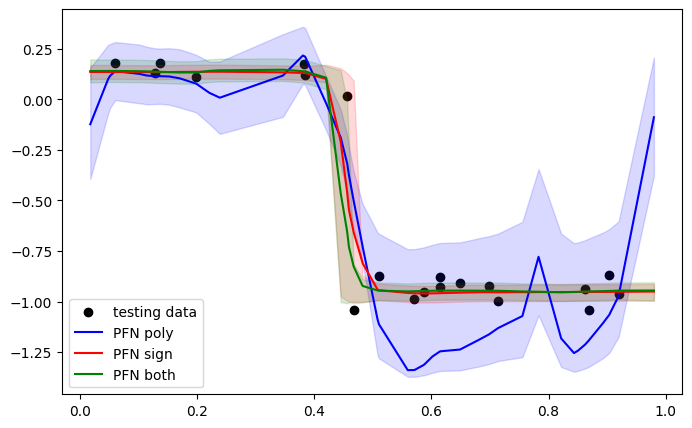

In [130]:
batch_index = 0  # change this to see other examples
num_training_points = 20

train_x = batch.x[batch_index, :num_training_points]
train_y = batch.y[batch_index, :num_training_points]
test_x  = batch.x[batch_index]

print(train_x.shape, train_y.shape, test_x.shape)

order_test_x = test_x[..., 0].argsort()

plt.figure(figsize=(8, 5))
plt.scatter(train_x[..., 0], train_y, color="black", label="testing data")

with torch.no_grad():
    # ----- model_poly (blue) -----
    logits_poly = model_poly(train_x[None], train_y[None], test_x[None])
    mean_poly = model_poly.criterion.mean(logits_poly)[0]
    conf_poly = model_poly.criterion.quantile(logits_poly)[0]

    plt.plot(
        test_x[order_test_x, 0],
        mean_poly[order_test_x],
        color="blue",
        label="PFN poly"
    )
    plt.fill_between(
        test_x[order_test_x, 0],
        conf_poly[..., 0][order_test_x],
        conf_poly[..., 1][order_test_x],
        color="blue",
        alpha=0.15
    )

    # ----- model_sign (red) -----
    logits_sign = model_sign(train_x[None], train_y[None], test_x[None])
    mean_sign = model_sign.criterion.mean(logits_sign)[0]
    conf_sign = model_sign.criterion.quantile(logits_sign)[0]

    plt.plot(
        test_x[order_test_x, 0],
        mean_sign[order_test_x],
        color="red",
        label="PFN sign"
    )
    plt.fill_between(
        test_x[order_test_x, 0],
        conf_sign[..., 0][order_test_x],
        conf_sign[..., 1][order_test_x],
        color="red",
        alpha=0.15
    )

    # ----- model_both_20 (purple) -----
    logits_both = model_both_20(train_x[None], train_y[None], test_x[None])
    mean_both = model_both_20.criterion.mean(logits_both)[0]
    conf_both = model_both_20.criterion.quantile(logits_both)[0]

    plt.plot(
        test_x[order_test_x, 0],
        mean_both[order_test_x],
        color="green",
        label="PFN both"
    )
    plt.fill_between(
        test_x[order_test_x, 0],
        conf_both[..., 0][order_test_x],
        conf_both[..., 1][order_test_x],
        color="green",
        alpha=0.15
    )

plt.legend()
plt.show()


torch.Size([10, 1]) torch.Size([10, 1]) torch.Size([50, 1])


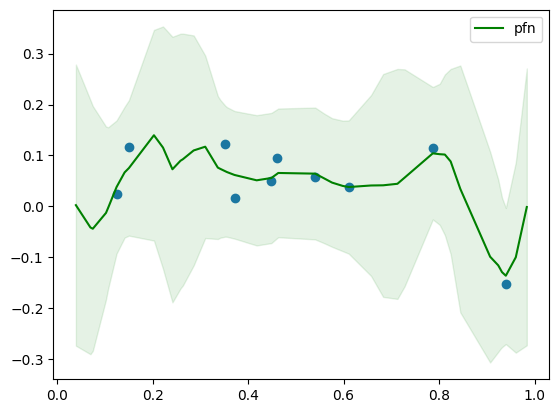

In [101]:
batch_index = 0 # change this to see other examples
num_training_points = 10


train_x = batch.x[batch_index, :num_training_points]
train_y = batch.y[batch_index, :num_training_points]
test_x = batch.x[batch_index]

print(train_x.shape, train_y.shape, test_x.shape)

with torch.no_grad():
    # we add our batch dimension, as our transformer always expects that
    logits = model(train_x[None], train_y[None], test_x[None])

# the model has the criterion still attached (it is the same though, as our criterion above)
# the criterion has a lot of handy function to use these logits
pred_means = model.criterion.mean(logits)[0]
pred_confs = model.criterion.quantile(logits)[0]


plt.scatter(train_x[...,0],train_y)
order_test_x = test_x[...,0].argsort()
plt.plot(test_x[order_test_x, ..., 0],pred_means[order_test_x], color='green', label='pfn')
plt.fill_between(test_x[order_test_x,0], pred_confs[...,0][order_test_x], pred_confs[...,1][order_test_x], alpha=.1, color='green')

import sklearn.linear_model

ridge_model = sklearn.linear_model.Ridge(alpha=(a/b)**2)
ridge_model.fit(train_x,train_y)
# plt.plot(test_x[order_test_x].squeeze(), ridge_model.predict(test_x[order_test_x]), label='ridge regression')
plt.legend()
plt.plot();

### Analysis of the performance of our trained PFN

In [ ]:
# let's sample some datasets to look at
batch = get_batch_for_ridge_regression(seq_len=100, hyperparameters=hps, batch_size=10)

In [ ]:
print(batch.x.shape)
print(batch.y.shape)
print(batch.target_y.shape)

x = batch.x
y = batch.y

with torch.no_grad():
    # we add our batch dimension, as our transformer always expects that
    logits = trained_model(x, y, x)
print(logits.shape)

torch.Size([10, 100, 1])
torch.Size([10, 100, 1])
torch.Size([10, 100, 1])
torch.Size([10, 100, 1000])


torch.Size([100, 1]) torch.Size([100, 1]) torch.Size([400, 1])


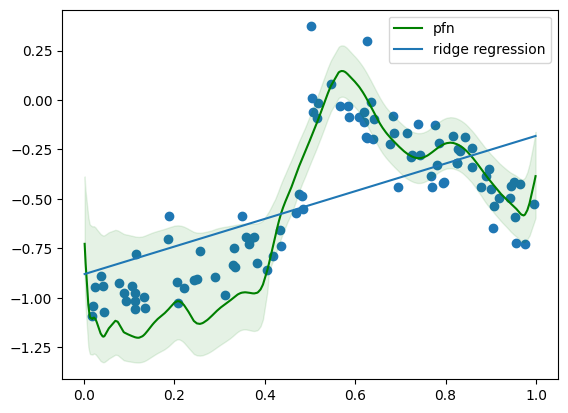

In [68]:
# our model wants the seq dimension first, remember that!

batch_index = 0 # change this to see other examples
num_training_points = 100


train_x = batch.x[batch_index, :num_training_points]
train_y = batch.y[batch_index, :num_training_points]
test_x = batch.x[batch_index]

print(train_x.shape, train_y.shape, test_x.shape)

with torch.no_grad():
    # we add our batch dimension, as our transformer always expects that
    logits = model_poly(train_x[None], train_y[None], test_x[None])

# the model has the criterion still attached (it is the same though, as our criterion above)
# the criterion has a lot of handy function to use these logits
pred_means = model_poly.criterion.mean(logits)[0]
pred_confs = model_poly.criterion.quantile(logits)[0]


plt.scatter(train_x[...,0],train_y)
order_test_x = test_x[...,0].argsort()
plt.plot(test_x[order_test_x, ..., 0],pred_means[order_test_x], color='green', label='pfn')
plt.fill_between(test_x[order_test_x,0], pred_confs[...,0][order_test_x], pred_confs[...,1][order_test_x], alpha=.1, color='green')

import sklearn.linear_model

ridge_model = sklearn.linear_model.Ridge(alpha=(a/b)**2)
ridge_model.fit(train_x,train_y)
plt.plot(test_x[order_test_x].squeeze(), ridge_model.predict(test_x[order_test_x]), label='ridge regression')
plt.legend()
plt.plot();

In [ ]:
import torch
def compute_nll(model, batch, eps=1e-12):
    x = batch.x.transpose(0, 1)
    y = batch.y.transpose(0, 1)
    target_y = batch.target_y.transpose(0, 1)

    with torch.no_grad():
      logits = model(x, y, x)

      borders = model.criterion.borders.to(logits.device)
      bin_centers = 0.5 * (borders[:-1] + borders[1:])


      probs = torch.softmax(logits, dim=-1)
      bin_widths = borders[1:] - borders[:-1]

      bin_idx = torch.bucketize(
          target_y.squeeze(-1),
          borders
      ) - 1

      bin_idx = bin_idx.clamp(0, bin_widths.shape[0] - 1)

      probs_correct = probs.gather(
          dim=-1,
          index=bin_idx.unsqueeze(-1)
      ).squeeze(-1)

      widths = bin_widths[bin_idx]
      density = probs_correct / widths

      nll = -torch.log(density + eps)
      nll = nll.mean().item()

    return nll
print(compute_nll(trained_model, batch))

def compute_mse_loss(model, batch):
    x = batch.x.transpose(0, 1)
    y = batch.y.transpose(0, 1)
    target_y = batch.target_y.transpose(0, 1)

    with torch.no_grad():
        logits = model(x, y, x)  # (

        probs = torch.softmax(logits, dim=-1)

        borders = model.criterion.borders.to(logits.device)
        bin_centers = 0.5 * (borders[:-1] + borders[1:])

        pred_mean = torch.sum(
            probs * bin_centers.view(1, 1, -1),
            dim=-1,
            keepdim=True
        )

        mse = torch.mean((pred_mean - target_y) ** 2).item()

    return mse


compute_mse_loss(trained_model, batch)


6.964451313018799


1.1106396913528442

Our model uses a Riemann distribution, that is a discretized distribution internally. We can show this here for one prediction.

### They seem to align kinda well..

.. at least for a PFN trained for 1 minute. If you are now interested in the more theoretical analysis why this prior yields ridge regression, please see https://statisticaloddsandends.wordpress.com/2018/12/29/bayesian-interpretation-of-ridge-regression/.

What we can also see is that our PFN provides us with confidence bounds, unlike ridge regression. This is actually the case out of the box. We use a discretized distribution (the riemann distribution). It can be described as
a piece-wise constant distribution. We just need to find out what good pieces are for our prior.
You can view the discretization in `trained_model.criterion.borders`. We fit them on a lot of samples from our prior.
If you are interested in the way we do regression, see read about the Riemann distribution in our paper https://arxiv.org/abs/2112.10510 or see the code in `bar_distribution.py`.

## Let's do some special stuff!!

So far we only reproduced an algorithm that already exists.
Let's try two more things.

### i) Sine Ridge Regression


What should **sine ridge regression** be!? It is the same as ridge regression, just that
we replace our curves with sines.

We can adapt the `get_batch` function from above to get there.

In [ ]:
def get_batch_for_sine_ridge_regression(batch_size=10,seq_len=100,num_features=1,
                                   hyperparameters=None, **kwargs):
    if hyperparameters is None:
        hyperparameters = {'a': 0.01, 'b': 1.0, 's': .3}
    ws = torch.distributions.Normal(torch.zeros(num_features+1), hyperparameters['b']).sample((batch_size,))

    xs = torch.rand(batch_size, seq_len, num_features)
    ys = torch.distributions.Normal(
        torch.einsum('nmf, nf -> nm',
                     torch.cat([xs,torch.ones(batch_size, seq_len,1)],2),
                     ws
                    ),
        hyperparameters['a']
    ).sample()

    ## the new part

    ys += torch.sin(xs[...,0]*20) * hyperparameters['s']

    ## end new part

    # get_batch functions return two different ys, let's come back to this later, though.
    return Batch(x=xs, y=ys[...,None], target_y=ys[...,None])



Let's sample from this prior...

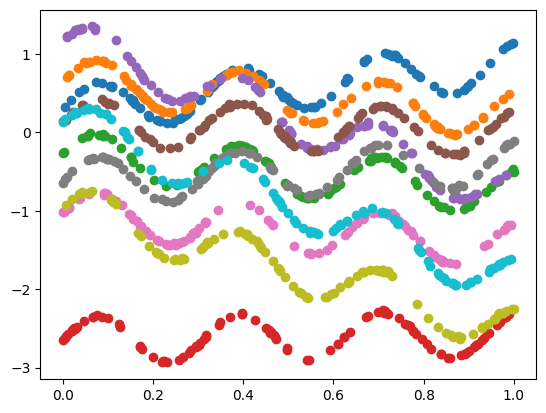

In [ ]:
batch = get_batch_for_sine_ridge_regression()
for dataset_index in range(len(batch.x)):
    plt.scatter(batch.x[dataset_index,:,0].numpy(), batch.y[dataset_index,:].numpy())

#### Funky curves, let's train a PFN!!!

In [ ]:
train_results_sine = train_a_pfn(get_batch_for_sine_ridge_regression, epochs=20)
trained_model_sine = train_results_sine['model']

init dist
Not using distributed
ALL: Using device cuda.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_sine_ridge_regression (batch_size=10, seq_len=100, num_features=1, hyperparameters=None, **kwargs)
), num_features=1, hyperparameters=None), 'num_steps': 100, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=256, min_single_eval_pos=0, max_seq_len=20, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'cuda', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_sine_ridge_regression (batch_size=10, seq_len=100, num_features=1, hyperparameters=None, **kwargs)
), num_features=1, hyperparameters=None), 'num_steps': 100, 

In [ ]:
batch = get_batch_for_sine_ridge_regression(seq_len=300)
# batch = get_batch_for_ridge_regression(seq_len=100, hyperparameters=hps, batch_size=10)


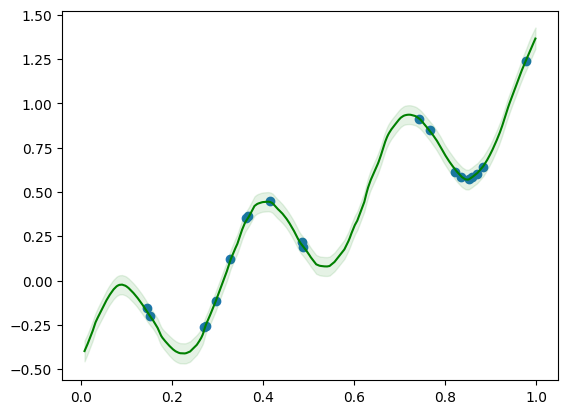

In [ ]:
# our model wants the seq dimension first, remember that!

batch_index = 2 # change this to see other examples
num_training_points = 20

train_x = batch.x[batch_index,:num_training_points]
train_y = batch.y[batch_index, :num_training_points]
test_x = batch.x[batch_index]

with torch.no_grad():
    # we add our batch dimension, as our transformer always expects that

    logits = trained_model_sine(train_x[None], train_y[None], test_x[None])
# the model has the criterion still attached (it is the same though, as our criterion above)
# the criterion has a lot of handy function to use these logits
pred_means = trained_model_sine.criterion.mean(logits)[0]
pred_confs = trained_model_sine.criterion.quantile(logits)[0]


plt.scatter(train_x[...,0],train_y)
order_test_x = test_x[...,0].argsort()
plt.plot(test_x[order_test_x],pred_means[order_test_x], color='green', label='pfn')
plt.fill_between(test_x[order_test_x,0], pred_confs[..., 0][order_test_x], pred_confs[...,1][order_test_x], alpha=.1, color='green')

We can see that the predictions appear, as we expect it, in a sine shape, too.

### ii) Anti-sine Regression. Let's play with `batch.target_y`

In all `get_batch` functions so far we specified two `y`s. We did this because there is a difference in how they are treated by the training loop. `batch.y` is used to feed it to the PFN as knowledge about the training set, while `batch.target_y` is used to train the transformer to predict it.

Typically we use a different `batch.target_y` s.t. we train not to fit the noise. In EI for example one often prefers EI over predictions that do not take inherent noise into account, as that changes the confidence intervals.

We will use the same prior as before, but make our model predict the middle of the sine wave instead of the wave itself.

In [ ]:
def get_batch_for_anti_sine_ridge_regression(batch_size=10,seq_len=100,num_features=1,
                                             hyperparameters=None, **kwargs):
    if hyperparameters is None:
        hyperparameters = {'a': 0.01, 'b': 1.0, 's': .3}
    ws = torch.distributions.Normal(torch.zeros(num_features+1), hyperparameters['b']).sample((batch_size,))

    xs = torch.rand(batch_size, seq_len, num_features)
    mean_ys = torch.einsum('nmf, nf -> nm',
                     torch.cat([xs,torch.ones(batch_size, seq_len,1)],2),
                     ws
                    )
    ys = torch.distributions.Normal(
        mean_ys,
        hyperparameters['a']
    ).sample()


    ys += torch.sin(xs[...,0]*20) * hyperparameters['s']


    # the new part is in target_y
    return Batch(x=xs, y=ys[...,None], target_y=mean_ys[...,None])




Let's visualize this for one example:

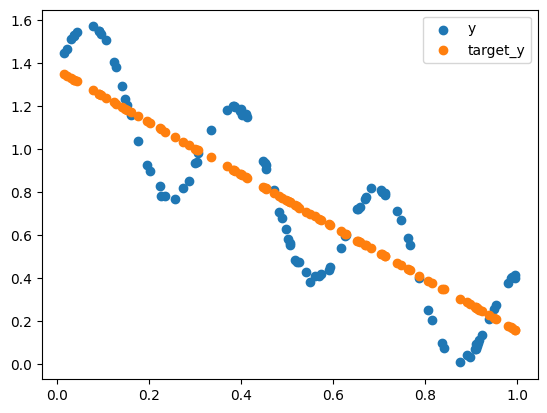

In [ ]:
batch = get_batch_for_anti_sine_ridge_regression()

plt.scatter(batch.x[dataset_index,:,0].numpy(), batch.y[dataset_index].numpy(), label='y')
plt.scatter(batch.x[dataset_index,:,0].numpy(), batch.target_y[dataset_index].numpy(), label='target_y')

plt.legend()
plt.show()

In [ ]:
# we use a large max_dataset_size s.t. we can show it with more training examples, which makes the effect more clear
train_results_anti_sine = train_a_pfn(get_batch_for_anti_sine_ridge_regression, batch_size=64, max_dataset_size=100)
trained_model_anti_sine = train_results_anti_sine['model']

init dist
Not using distributed
ALL: Using device cuda.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_anti_sine_ridge_regression (batch_size=10, seq_len=100, num_features=1, hyperparameters=None, **kwargs)
), num_features=1, hyperparameters=None), 'num_steps': 100, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=64, min_single_eval_pos=0, max_seq_len=100, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'cuda', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_anti_sine_ridge_regression (batch_size=10, seq_len=100, num_features=1, hyperparameters=None, **kwargs)
), num_features=1, hyperparameters=None), 'num_ste

If you see "nan" in the positional losses in the training log above that just means this particular `single_eval_pos` was not sampled.

In [ ]:
# our model wants the seq dimension first, remember that!

batch_index = 0 # change this to see other examples
num_training_points = 50

train_x = batch.x[batch_index, :num_training_points]
train_y = batch.y[batch_index, :num_training_points]
test_x = batch.x[batch_index]

with torch.no_grad():
    # we add our batch dimension, as our transformer always expects that
    logits = trained_model_anti_sine(train_x[None], train_y[None], test_x[None])

# the model has the criterion still attached (it is the same though, as our criterion above)
# the criterion has a lot of handy function to use these logits
pred_means = trained_model_anti_sine.criterion.mean(logits)[0]
pred_confs = trained_model_anti_sine.criterion.quantile(logits)[0]


plt.scatter(train_x[...,0],train_y)
order_test_x = test_x[...,0].argsort()
plt.plot(test_x[order_test_x, ..., 0],pred_means[order_test_x], color='green', label='pfn')
plt.fill_between(test_x[order_test_x, ..., 0], pred_confs[..., 0][order_test_x], pred_confs[...,1][order_test_x], alpha=.1, color='green')

It looks like we can actually reconstruct the mean of the sine. This might be helpful for some obscure regression with a sine based noise..

### ONE ENCORE!! Let's do a GP as finale (and calculate EI on it)

For this we will use a prior that is already part of the pacakge in the `priors` folder. This folder is generally useful to store priors.

You can already have a sneak peak at what we will get out here, in our demo https://huggingface.co/spaces/samuelinferences/transformers-can-do-bayesian-inference

We will start by sampling some datasets in 1d from GP.

In [ ]:
from pfns.priors.fast_gp import get_batch as get_batch_for_gp

batch = get_batch_for_gp(batch_size=2, seq_len=100, num_features=1, hyperparameters={"noise": 1e-4, "outputscale": 1., "lengthscale": 0.1})
for dataset_index in range(len(batch.x)):
    plt.scatter(batch.x[dataset_index,:,0].cpu().numpy(), batch.y[dataset_index,:].cpu().numpy())

### Now we can go ahead and train a PFN, let's go 🚂

In [ ]:
from pfns import priors

training_output_gp = train_a_pfn(get_batch_for_gp, hps={"noise": 1e-4, "outputscale": 1., "lengthscale": 0.1})
trained_model_gp = training_output_gp['model']

In [ ]:
# our model wants the seq dimension first, remember that!

batch = get_batch_for_gp(batch_size=2, seq_len=100, num_features=1, hyperparameters={"noise": 1e-4, "outputscale": 1., "lengthscale": 0.1})

batch_index = 0 # change this to see other examples
num_training_points = 5

train_x = batch.x[batch_index, :num_training_points].cpu()
train_y = batch.y[batch_index, :num_training_points].cpu()
test_x = batch.x[batch_index].cpu()

with torch.no_grad():
    # we add our batch dimension, as our transformer always expects that
    logits = trained_model_gp(train_x[None], train_y[None], test_x[None])

# the model has the criterion still attached (it is the same though, as our criterion above)
# the criterion has a lot of handy function to use these logits
pred_means = trained_model_gp.criterion.mean(logits)[0]
pred_confs = trained_model_gp.criterion.quantile(logits)[0]

plt.scatter(train_x[...,0],train_y)
order_test_x = test_x[...,0].argsort()
plt.plot(test_x[order_test_x, ..., 0],pred_means[order_test_x], color='green', label='pfn')
plt.fill_between(test_x[order_test_x, ..., 0], pred_confs[..., 0][order_test_x], pred_confs[...,1][order_test_x], alpha=.1, color='green')

### WE CAN CALCULATE THE EI LIKE THIS:
pred_ei = trained_model_gp.criterion.ei(logits, best_f=max(train_y))

plt.figure()
plt.title('EI')
plt.plot(test_x[order_test_x, ..., 0], pred_ei[0,order_test_x], color='green', label='ei')
plt.show()